Sample Dataset
   Day     Glucose
0    1  102.483571
1    2  101.306227
2    3  107.194046
3    4  113.450807
4    5  106.430392


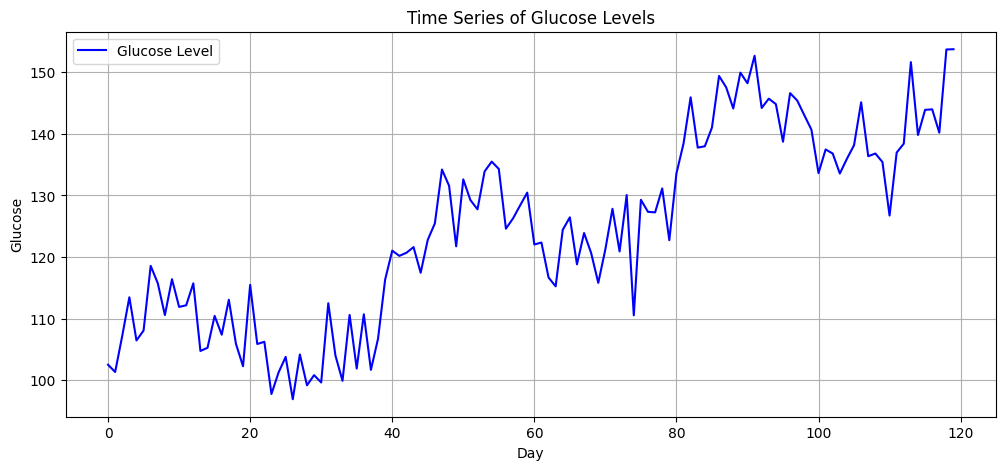

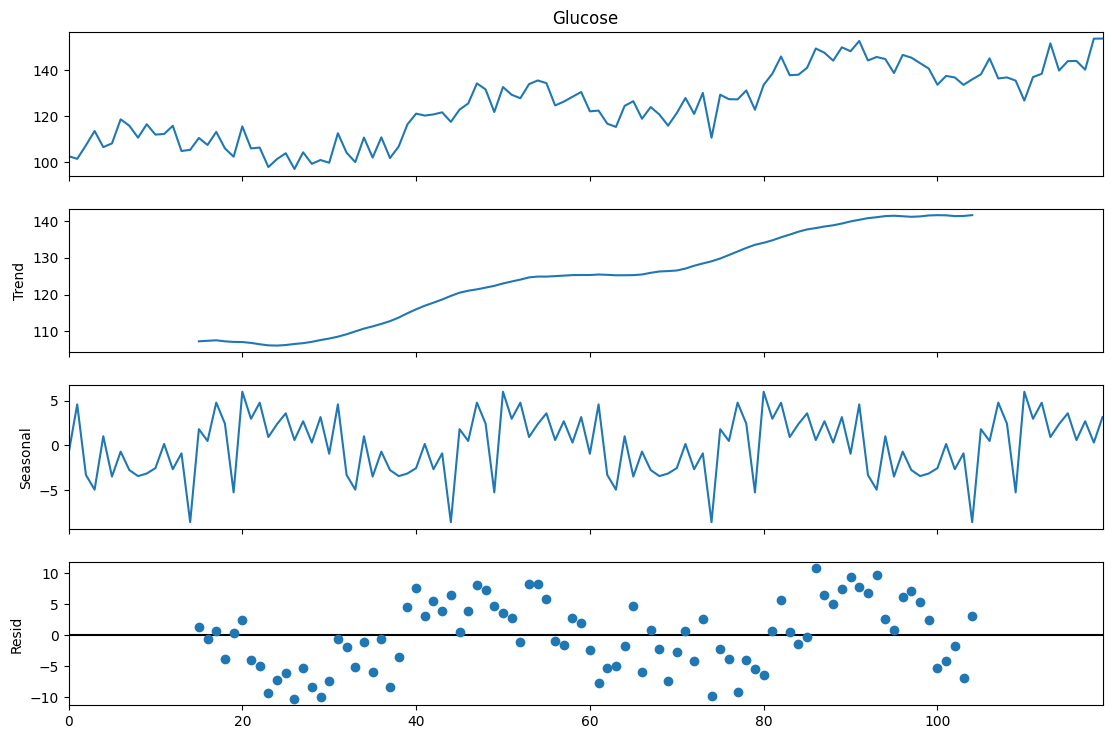

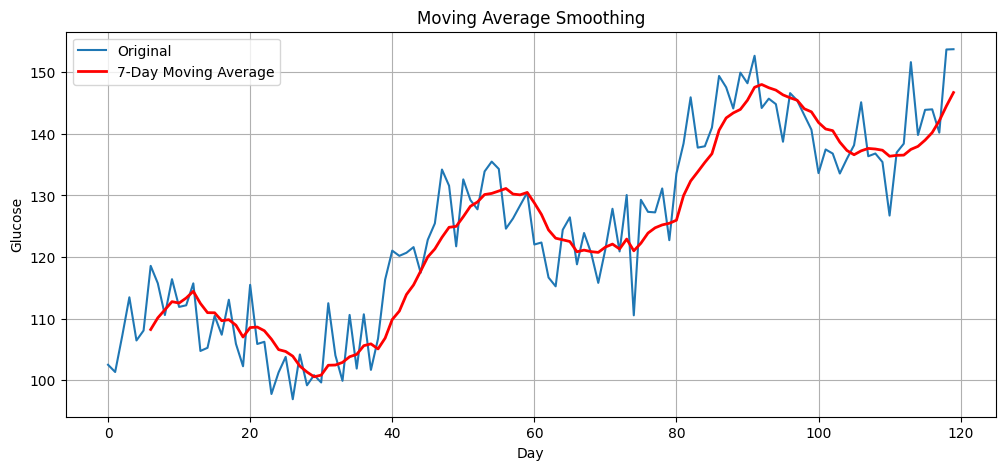

C:\Users\pashv\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\pashv\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


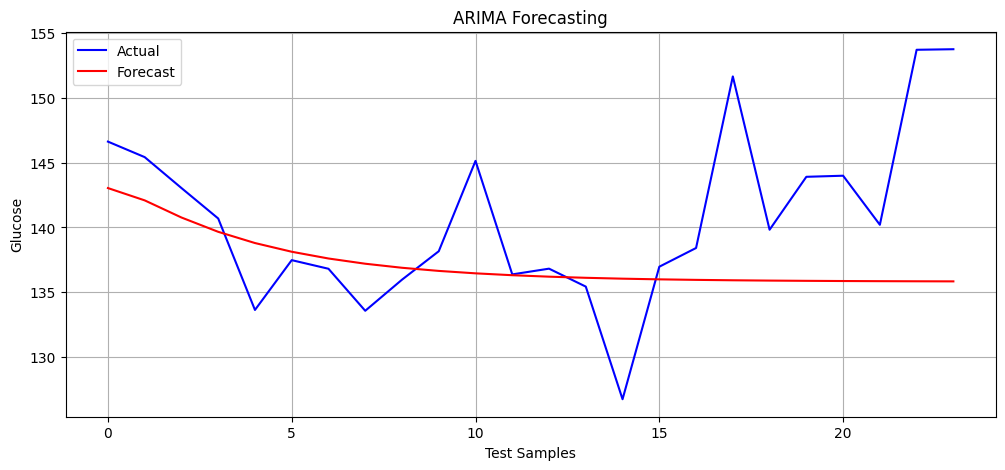


Forecast Results
       Actual    Forecast
0  146.625016  143.037115
1  145.426593  142.086686
2  143.039533  140.763607
3  140.687672  139.658570
4  133.623786  138.791778


In [4]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# ------------------------------------------
# Create Sample Time Series Dataset
# ------------------------------------------

np.random.seed(42)

days = 120

trend = np.linspace(100, 150, days)
seasonal = 10 * np.sin(np.linspace(0, 6*np.pi, days))
noise = np.random.normal(0, 5, days)

glucose = trend + seasonal + noise

diabetes_data = pd.DataFrame({
    "Day": range(1, days + 1),
    "Glucose": glucose
})

print("Sample Dataset")
print(diabetes_data.head())

# ------------------------------------------
# Plot Time Series
# ------------------------------------------

plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], color="blue", label="Glucose Level")
plt.title("Time Series of Glucose Levels")
plt.xlabel("Day")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# Seasonal Decomposition
# ------------------------------------------

decomposition = seasonal_decompose(
    diabetes_data["Glucose"],
    model="additive",
    period=30
)

fig = decomposition.plot()
fig.set_size_inches(12,8)
plt.show()

# ------------------------------------------
# Moving Average
# ------------------------------------------

diabetes_data["Glucose_MA"] = (
    diabetes_data["Glucose"]
    .rolling(window=7)
    .mean()
)

plt.figure(figsize=(12,5))
plt.plot(diabetes_data["Glucose"], label="Original")
plt.plot(diabetes_data["Glucose_MA"],
         color="red",
         linewidth=2,
         label="7-Day Moving Average")

plt.title("Moving Average Smoothing")
plt.xlabel("Day")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# ARIMA Forecasting
# ------------------------------------------

train_size = int(len(diabetes_data) * 0.8)

train = diabetes_data["Glucose"][:train_size]
test = diabetes_data["Glucose"][train_size:]

model = ARIMA(train, order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=len(test))

# ------------------------------------------
# Plot Forecast
# ------------------------------------------

plt.figure(figsize=(12,5))

plt.plot(test.values,
         label="Actual",
         color="blue")

plt.plot(forecast.values,
         label="Forecast",
         color="red")

plt.title("ARIMA Forecasting")
plt.xlabel("Test Samples")
plt.ylabel("Glucose")
plt.legend()
plt.grid(True)
plt.show()

# ------------------------------------------
# Forecast Values
# ------------------------------------------

forecast_df = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast.values
})

print("\nForecast Results")
print(forecast_df.head())